In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from collections import Counter, defaultdict
from nltk.corpus import stopwords
import nltk
from wordcloud import WordCloud
import warnings

warnings.filterwarnings("ignore")
nltk.download("stopwords")
nltk.download("punkt")
from nltk.tokenize import word_tokenize

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 12

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MESK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MESK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# **Load IMDB Dataset**


In [2]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
print(f"Dataset Shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset Shape: (50000, 2)

Column names: ['review', 'sentiment']

Data types:
review       object
sentiment    object
dtype: object

Missing values:
review       0
sentiment    0
dtype: int64


In [4]:
class_counts = df["sentiment"].value_counts()
print(f"Class distribution:")
for sentiment, count in class_counts.items():
    print(f"  {sentiment}: {count} ({count/len(df)*100:.2f}%)")

Class distribution:
  positive: 25000 (50.00%)
  negative: 25000 (50.00%)


## **Extract Most Common Words**

Finds and returns the most frequent words from positive and negative reviews, with optional stopword removal.


In [5]:
pos_reviews = df[df["sentiment"] == "positive"]
neg_reviews = df[df["sentiment"] == "negative"]


def get_top_n_words(text_series, n=20, remove_stopwords=True):
    all_text = " ".join(text_series.values)  # Combine all reviews into one string
    all_text = all_text.lower()  # Convert to lowercase
    all_text = re.sub(r"<br />", " ", all_text)  # Remove HTML line break tags
    all_text = re.sub(r"[^a-zA-Z\s]", "", all_text)  # Keep only letters and spaces
    words = all_text.split()  # Split into individual words
    if remove_stopwords:
        stop_words = set(stopwords.words("english"))
        words = [w for w in words if w not in stop_words]  # Remove stopwords
    word_counts = Counter(words)  # Count frequency of each word

    return word_counts.most_common(n)  # Return top n most frequent words


top_words_pos = get_top_n_words(
    pos_reviews["review"], n=20
)  # Top 20 words in positive reviews
top_words_neg = get_top_n_words(
    neg_reviews["review"], n=20
)  # Top 20 words in negative reviews

## **Generate Word Cloud Visualization**

Creates a word cloud image showing most frequent words, with larger text for more common words.


In [6]:
def generate_wordcloud(text_series, title, color="coolwarm"):
    all_text = " ".join(text_series.values)
    all_text = all_text.lower()
    all_text = re.sub(r"<br />", " ", all_text)
    all_text = re.sub(r"[^a-zA-Z\s]", "", all_text)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap=color,
        max_words=200,
        contour_width=1,
        contour_color="steelblue",
    ).generate(all_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(title, fontsize=16, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    return wordcloud

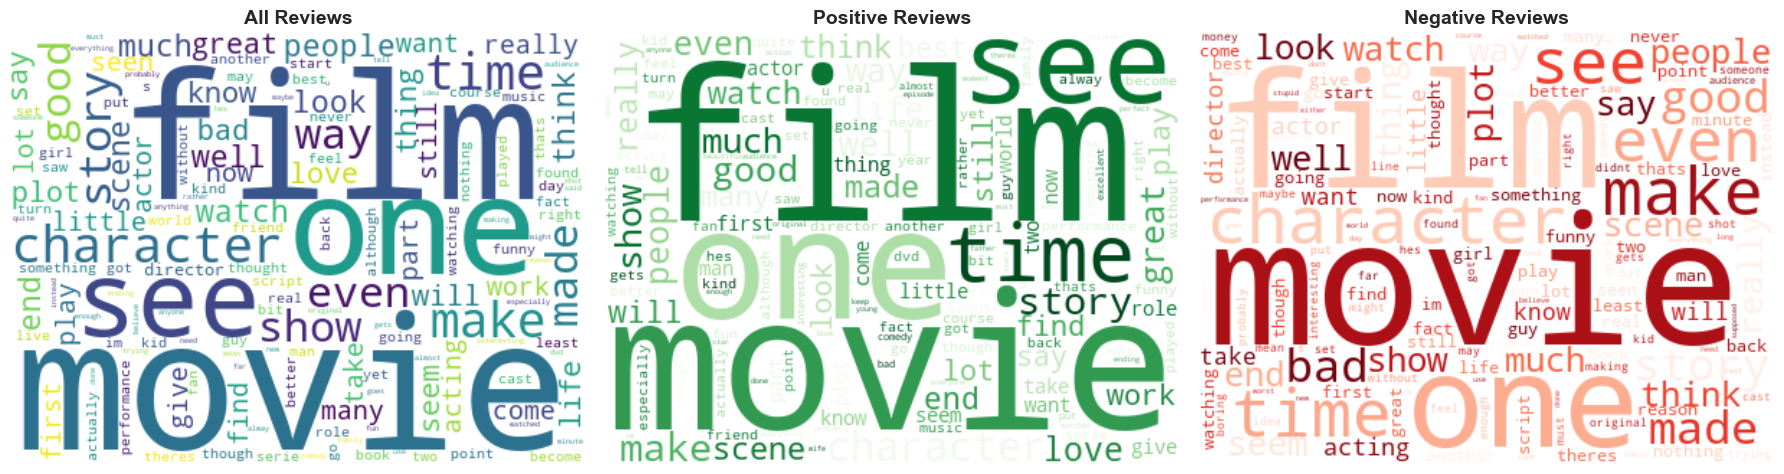

In [7]:
# Generate word clouds
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# All reviews
all_text = " ".join(df["review"].values)
all_text = re.sub(r"<br />", " ", all_text.lower())
all_text = re.sub(r"[^a-zA-Z\s]", "", all_text)
wc_all = WordCloud(
    width=400, height=300, background_color="white", max_words=150
).generate(all_text)
axes[0].imshow(wc_all, interpolation="bilinear")
axes[0].set_title("All Reviews", fontsize=14, fontweight="bold")
axes[0].axis("off")

# Positive reviews
pos_text = " ".join(pos_reviews["review"].values)
pos_text = re.sub(r"<br />", " ", pos_text.lower())
pos_text = re.sub(r"[^a-zA-Z\s]", "", pos_text)
wc_pos = WordCloud(
    width=400, height=300, background_color="white", colormap="Greens", max_words=150
).generate(pos_text)
axes[1].imshow(wc_pos, interpolation="bilinear")
axes[1].set_title("Positive Reviews", fontsize=14, fontweight="bold")
axes[1].axis("off")

# Negative reviews
neg_text = " ".join(neg_reviews["review"].values)
neg_text = re.sub(r"<br />", " ", neg_text.lower())
neg_text = re.sub(r"[^a-zA-Z\s]", "", neg_text)
wc_neg = WordCloud(
    width=400, height=300, background_color="white", colormap="Reds", max_words=150
).generate(neg_text)
axes[2].imshow(wc_neg, interpolation="bilinear")
axes[2].set_title("Negative Reviews", fontsize=14, fontweight="bold")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## **Calculate Word Sentiment Polarity Score**

Analyzes each word's association with positive or negative sentiment based on review labels.

Example: Word "excellent" appears in 500 reviews
480 of those reviews are positive (1), 20 are negative (0)
Score = (480×1 + 20×0) / 500 = 0.96 (96% positive)


In [8]:
from collections import defaultdict  # Creates dictionary with default values


def calculate_word_sentiment_score(df, top_n=30):
    word_sentiment = defaultdict(list)  # Store sentiment scores for each word

    for idx, row in df.iterrows():  # Loop through each review
        sentiment = (
            1 if row["sentiment"] == "positive" else 0
        )  # Convert to binary (1=positive, 0=negative)
        words = set(
            re.sub(r"[^a-zA-Z\s]", "", row["review"].lower()).split()
        )  # Clean and get unique words

        for word in words:
            if len(word) > 3:  # Only consider words longer than 3 letters
                word_sentiment[word].append(sentiment)  # Add sentiment to word's list

    word_scores = {}
    for word, scores in word_sentiment.items():
        if len(scores) > 100:  # Only words appearing in 100+ reviews
            word_scores[word] = np.mean(scores)  # Average sentiment (0-1 scale)

    sorted_words = sorted(
        word_scores.items(), key=lambda x: x[1], reverse=True
    )  # Sort by sentiment score

    print(" Most POSITIVE-associated words (appearing >100 times):")
    for word, score in sorted_words[:15]:  # Top 15 most positive
        print(f"   {word}: {score:.3f} ({(score*100):.1f}% positive)")

    print("\n Most NEGATIVE-associated words (appearing >100 times):")
    for word, score in sorted_words[-15:][::-1]:  # Bottom 15 most negative
        print(f"   {word}: {score:.3f} ({(score*100):.1f}% positive)")


calculate_word_sentiment_score(df)

 Most POSITIVE-associated words (appearing >100 times):
   matthau: 0.922 (92.2% positive)
   flawless: 0.905 (90.5% positive)
   perfection: 0.894 (89.4% positive)
   understated: 0.887 (88.7% positive)
   superbly: 0.886 (88.6% positive)
   wonderfully: 0.882 (88.2% positive)
   mustsee: 0.881 (88.1% positive)
   heartbreaking: 0.872 (87.2% positive)
   captures: 0.870 (87.0% positive)
   unforgettable: 0.869 (86.9% positive)
   delightfully: 0.865 (86.5% positive)
   refreshing: 0.864 (86.4% positive)
   heartwarming: 0.864 (86.4% positive)
   beautifully: 0.863 (86.3% positive)
   timeless: 0.863 (86.3% positive)

 Most NEGATIVE-associated words (appearing >100 times):
   stinker: 0.041 (4.1% positive)
   mstk: 0.055 (5.5% positive)
   unwatchable: 0.060 (6.0% positive)
   godawful: 0.067 (6.7% positive)
   waste: 0.068 (6.8% positive)
   incoherent: 0.077 (7.7% positive)
   unfunny: 0.083 (8.3% positive)
   wasting: 0.085 (8.5% positive)
   camcorder: 0.088 (8.8% positive)
   driv

## **Text Cleaning Function**

Removes HTML tags, punctuation, numbers, and stopwords to prepare text for analysis.


In [9]:
def clean_text(text, remove_stopwords=True):
    # Step 1: Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)  # Remove any HTML tags like <br>
    text = re.sub(r"<br\s*/?>", " ", text)  # Specifically target <br /> tags

    # Step 2: Normalize text
    text = text.lower()  # Convert everything to lowercase
    text = re.sub(r"[^\w\s]", " ", text)  # Remove punctuation (!,?,., etc.)
    text = re.sub(r"\d+", " ", text)  # Remove numbers (123, 456)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)  # Keep only letters and spaces
    text = re.sub(r"\s+", " ", text)  # Remove extra spaces
    text = text.strip()  # Trim whitespace from ends

    # Step 3: Remove stopwords (optional)
    if remove_stopwords:
        stop_words = set(stopwords.words("english"))  # Common words: 'the', 'and', 'a'
        movie_stopwords = {
            "movie",
            "film",
            "scene",
            "character",
            "plot",  # Movie-specific common words
            "story",
            "watch",
            "see",
            "make",
            "time",
            "way",
            "really",
            "get",
            "even",
            "also",
            "well",
            "go",
        }
        stop_words.update(movie_stopwords)  # Combine both stopword sets

        words = text.split()  # Split into individual words
        words = [word for word in words if word not in stop_words]  # Remove stopwords
        text = " ".join(words)  # Join words back together

    return text  # Return cleaned text

In [10]:
print("Sample before cleaning:\n")
print(df["review"].iloc[1])
df["review"] = df["review"].apply(lambda x: clean_text(x, remove_stopwords=True))
print("\nSample before cleaning:\n")
print(df["review"].iloc[1])

Sample before cleaning:

A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) 

In [11]:
def get_top_words_after_cleaning(df, sentiment_label, n=20):
    """Get top words from cleaned reviews by sentiment"""
    filtered_df = df[
        df["sentiment"] == sentiment_label
    ]  # Filter positive or negative reviews
    all_text = " ".join(
        filtered_df["review"].values
    )  # Combine all reviews into one string
    words = all_text.split()  # Split into individual words
    word_counts = Counter(words)  # Count frequency of each word
    return word_counts.most_common(n)  # Return top n most frequent words


top_pos_cleaned = get_top_words_after_cleaning(df, "positive", 20)
top_neg_cleaned = get_top_words_after_cleaning(df, "negative", 20)

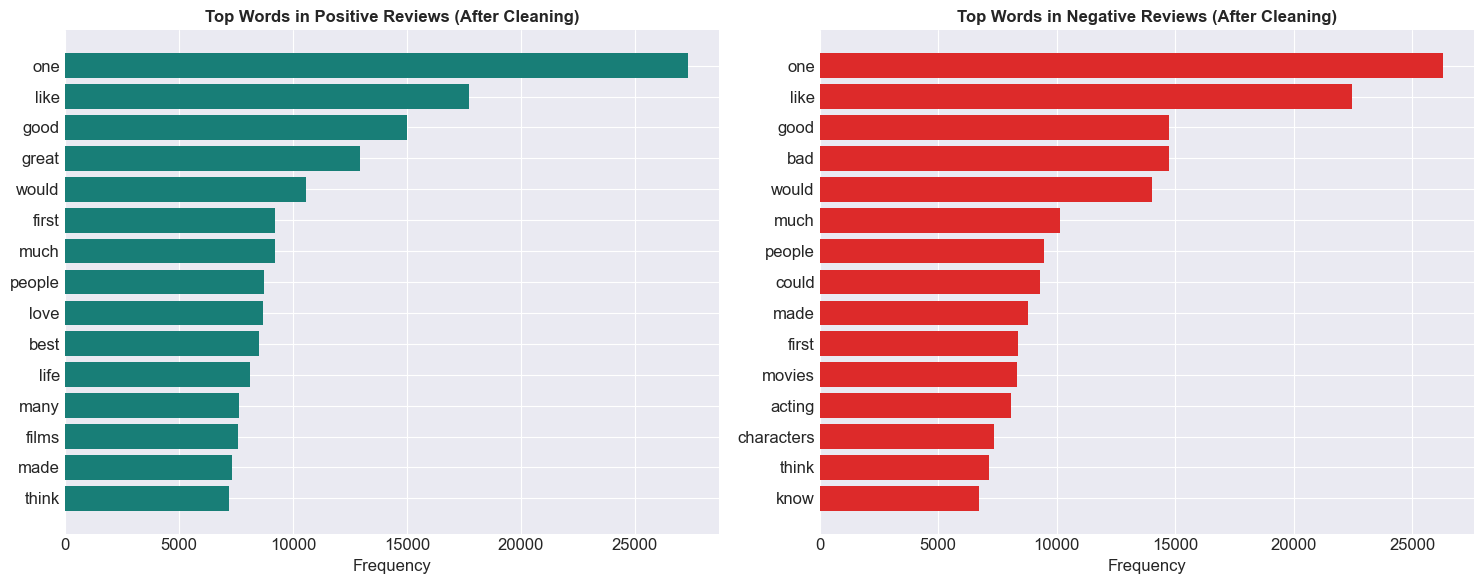

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

words_pos, counts_pos = zip(*top_pos_cleaned[:15])
axes[0].barh(words_pos, counts_pos, color="#187e77")
axes[0].set_title(
    "Top Words in Positive Reviews (After Cleaning)", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Frequency")
axes[0].invert_yaxis()

words_neg, counts_neg = zip(*top_neg_cleaned[:15])
axes[1].barh(words_neg, counts_neg, color="#dd2a2a")
axes[1].set_title(
    "Top Words in Negative Reviews (After Cleaning)", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Frequency")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [13]:
df["label"] = df["sentiment"].apply(lambda x: 1 if x == "positive" else 0)

X = df["review"].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## **TF-IDF Vectorization**

Converts text reviews into numerical feature vectors based on word importance.


In [14]:
tfidf = TfidfVectorizer(
    max_features=35000,
    ngram_range=(1, 3),  # Use single words, pairs, and triplets (1-3 words)
    stop_words="english",
    min_df=2,  # Ignore words that appear in less than 2 documents
    max_df=0.7,  # Ignore words that appear in more than 70% of documents
    sublinear_tf=True,
    use_idf=True,  # Penalize words that appear in many documents
    smooth_idf=True,  # Add 1 to document frequency to avoid division by zero
    norm="l2",  # Normalize vectors to unit length (Euclidean norm)
)

X_train_tfidf = tfidf.fit_transform(
    X_train
)  # Learn vocabulary + transform training data
X_test_tfidf = tfidf.transform(X_test)  # Transform test data using same vocabulary

## **Logistic Regression Model Training**

Trains a logistic regression classifier on TF-IDF features to predict sentiment.


In [15]:
log_reg = LogisticRegression(
    C=1.5,  # Inverse regularization strength (lower = stronger regularization)
    max_iter=1000,
    random_state=42,
    class_weight="balanced",  # Automatically adjust weights for imbalanced classes
)

log_reg.fit(X_train_tfidf, y_train)  # Train model on TF-IDF features with labels

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.5
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [16]:
y_pred = log_reg.predict(X_test_tfidf)
y_pred_proba = log_reg.predict_proba(X_test_tfidf)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [17]:
print(f"   Accuracy: ({accuracy*100:.2f}%)")
print(f"   Precision:({precision*100:.2f}%)")
print(f"   Recall:  ({recall*100:.2f}%)")
print(f"   F1-Score: ({f1*100:.2f}%)")

   Accuracy: (90.28%)
   Precision:(89.23%)
   Recall:  (91.62%)
   F1-Score: (90.41%)


In [18]:
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.92      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



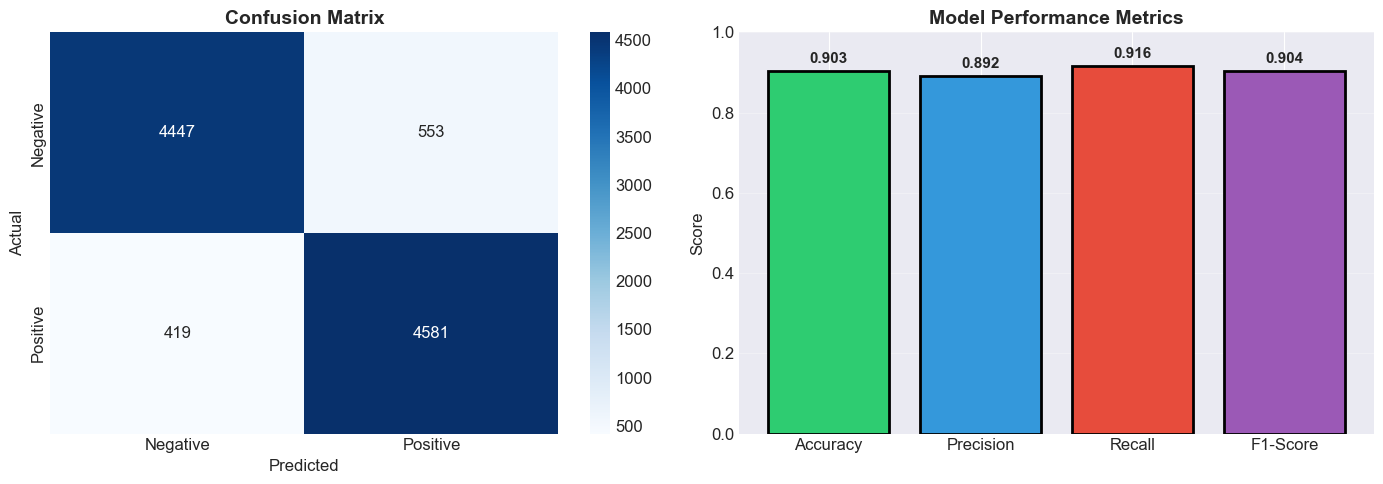

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = [accuracy, precision, recall, f1]
colors = ["#2ecc71", "#3498db", "#e74c3c", "#9b59b6"]

bars = axes[1].bar(metrics, values, color=colors, edgecolor="black", linewidth=2)
axes[1].set_ylim(0, 1)
axes[1].set_title("Model Performance Metrics", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Score")
axes[1].grid(True, alpha=0.3, axis="y")

for bar, val in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.3f}",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

## **Top Sentiment Words Visualization**

Extracts and plots the most influential words for positive and negative sentiment based on model coefficients.

#### **HOW IT WORKS:**

When the model sees a word with a high positive score, it pushes prediction toward "positive"
When it sees a word with a high negative score, it pushes prediction toward "negative"
The model adds up all word scores to make final decision


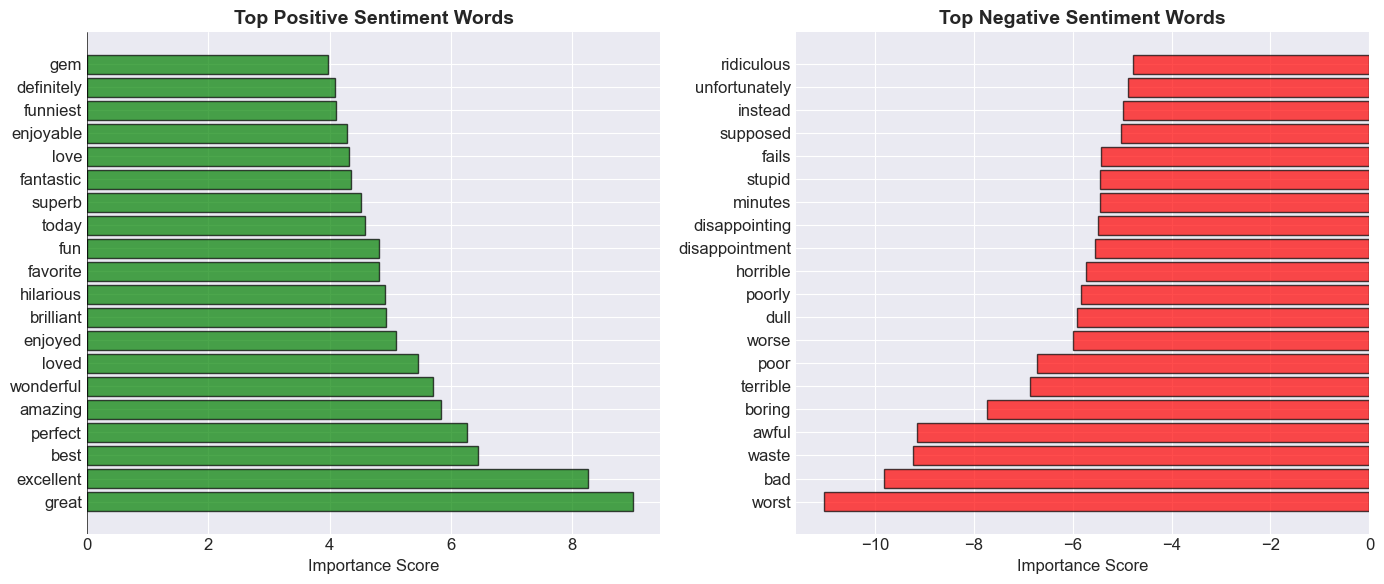

In [20]:
feature_names = tfidf.get_feature_names_out()  # Get all feature (word) names
coefficients = log_reg.coef_[0]  # Get importance scores for each word

top_positive_idx = np.argsort(coefficients)[-20:][
    ::-1
]  # Indices of 20 most positive words
top_negative_idx = np.argsort(coefficients)[:20]  # Indices of 20 most negative words

fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # Create side-by-side plots

# Positive words plot
pos_words = [feature_names[i] for i in top_positive_idx]  # Word names
pos_coef = [coefficients[i] for i in top_positive_idx]  # Importance scores
axes[0].barh(
    pos_words, pos_coef, color="green", alpha=0.7, edgecolor="black"
)  # Horizontal bar chart
axes[0].set_title("Top Positive Sentiment Words", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Importance Score")
axes[0].axvline(x=0, color="black", linestyle="-", linewidth=0.5)  # Zero line

# Negative words plot
neg_words = [feature_names[i] for i in top_negative_idx]  # Word names
neg_coef = [coefficients[i] for i in top_negative_idx]  # Importance scores
axes[1].barh(neg_words, neg_coef, color="red", alpha=0.7, edgecolor="black")
axes[1].set_title("Top Negative Sentiment Words", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Importance Score")
axes[1].axvline(x=0, color="black", linestyle="-", linewidth=0.5)

plt.tight_layout()
plt.show()

In [21]:
confidence = np.where(y_pred == 1, y_pred_proba, 1 - y_pred_proba)

correct_pred = y_pred == y_test
confident_correct = confidence[correct_pred]
confident_incorrect = confidence[~correct_pred]

print(f"Correct predictions avg confidence: {confident_correct.mean():.3f}")
print(f"Incorrect predictions avg confidence: {confident_incorrect.mean():.3f}")

Correct predictions avg confidence: 0.855
Incorrect predictions avg confidence: 0.659


## **Attack 1: ART white-box attack using FGSM (Fast Gradient Sign Method)**

How FGSM works:

1. Compute loss gradient w.r.t. TF-IDF features
2. Add small perturbation in gradient direction
3. Result: TF-IDF vector is slightly modified
4. When decoded back: some word weights change, some noise appears

In [41]:
# Install ART (Adversarial Robustness Toolbox)
import subprocess
import sys

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "adversarial-robustness-toolbox"]
)

# Import ART components for white-box attack
from art.estimators.classification import SklearnClassifier
from art.attacks.evasion import FastGradientMethod

In [35]:
# Wrap the logistic regression model for ART.
# ART computes gradients w.r.t. TF-IDF feature space to generate perturbations.
art_classifier = SklearnClassifier(
    model=log_reg,
    clip_values=(
        X_test_tfidf.min(),
        X_test_tfidf.max(),
    ),  # Constraint TF-IDF values to valid range
)

# FGSM: Add small perturbation in direction of gradient (sign of loss gradient).
# eps controls the perturbation magnitude
fgsm_attack = FastGradientMethod(
    estimator=art_classifier, eps=0.1, eps_step=0.01, norm="inf"
)

# Generate adversarial examples using FGSM on TF-IDF feature vectors.
X_test_adv_fgsm = fgsm_attack.generate(X_test_tfidf.toarray())

# Convert back to sparse matrix for prediction (same format as training).
from scipy.sparse import csr_matrix

X_test_adv_fgsm_sparse = csr_matrix(X_test_adv_fgsm)

# Get baseline predictions and probabilities.
base_pred = log_reg.predict(X_test_tfidf)
base_proba = log_reg.predict_proba(X_test_tfidf)

# Evaluate FGSM attack performance.
fgsm_pred = log_reg.predict(X_test_adv_fgsm_sparse)
fgsm_proba = log_reg.predict_proba(X_test_adv_fgsm_sparse)
fgsm_acc = (fgsm_pred == y_test).mean()

# Calculate attack success rate (originally correct samples that became wrong).
orig_correct = base_pred == y_test
becomes_wrong = (fgsm_pred != y_test) & orig_correct
attack_success_rate = becomes_wrong.sum() / max(orig_correct.sum(), 1)

In [36]:
# Print performance metrics.
print(f"Baseline accuracy:                 {(base_pred == y_test).mean():.4f}")
print(f"Adversarial (FGSM) accuracy:       {fgsm_acc:.4f}")
print(
    f"Accuracy drop:                     {(base_pred == y_test).mean() - fgsm_acc:.4f}"
)
print(
    f"Attack success rate:               {attack_success_rate:.4f} (flipped {becomes_wrong.sum()} of {orig_correct.sum()} correct samples)"
)

Baseline accuracy:                 0.9028
Adversarial (FGSM) accuracy:       0.0972
Accuracy drop:                     0.8056
Attack success rate:               1.0000 (flipped 9028 of 9028 correct samples)


In [38]:
# Display concrete before/after examples.
print("BEFORE/AFTER EXAMPLES (Samples where prediction flipped):")

# Find indices where the attack succeeded.
flip_idx = np.where(becomes_wrong)[0][:3]  # Show up to 3 examples

for ex_num, idx in enumerate(flip_idx, 1):
    print(f"\n{'─' * 70}")
    print(f"EXAMPLE {ex_num} (Sample Index: {idx})")
    print(f"{'─' * 70}")

    # True label.
    true_label = y_test[idx]
    print(f"True Label: {'POSITIVE (1)' if true_label == 1 else 'NEGATIVE (0)'}")

    # Original text preview.
    print(f"\nOriginal Text Preview: {X_test[idx][:150]}...")

    # BEFORE attack.
    print(f"\nBEFORE ATTACK:")
    print(f"   Prediction: {'POSITIVE (1)' if base_pred[idx] == 1 else 'NEGATIVE (0)'}")
    print(f"   Confidence: {max(base_proba[idx]):.4f}")
    print(f"   Probability [Negative, Positive]: {base_proba[idx]}")

    # AFTER attack.
    print(f"\nAFTER ATTACK (FGSM):")
    print(f"   Prediction: {'POSITIVE (1)' if fgsm_pred[idx] == 1 else 'NEGATIVE (0)'}")
    print(f"   Confidence: {max(fgsm_proba[idx]):.4f}")
    print(f"   Probability [Negative, Positive]: {fgsm_proba[idx]}")

BEFORE/AFTER EXAMPLES (Samples where prediction flipped):

──────────────────────────────────────────────────────────────────────
EXAMPLE 1 (Sample Index: 0)
──────────────────────────────────────────────────────────────────────
True Label: NEGATIVE (0)

Original Text Preview: yes mtv market daria started clever teenage angst comment everything sucks viewer feel better sucky teenage life sitcom mutated deal problems charade ...

BEFORE ATTACK:
   Prediction: NEGATIVE (0)
   Confidence: 0.6749
   Probability [Negative, Positive]: [0.67494391 0.32505609]

AFTER ATTACK (FGSM):
   Prediction: POSITIVE (1)
   Confidence: 1.0000
   Probability [Negative, Positive]: [0. 1.]

──────────────────────────────────────────────────────────────────────
EXAMPLE 2 (Sample Index: 1)
──────────────────────────────────────────────────────────────────────
True Label: NEGATIVE (0)

Original Text Preview: bride fair amusing engaging one filmmaker credit sets portray rural minnesotans respect ordinarily reser

In [40]:
# Analyze which TF-IDF features were most affected by FGSM perturbations.
# This shows which words/phrases the attack modified the most.

for ex_num, idx in enumerate(flip_idx, 1):
    # Calculate the difference between adversarial and original TF-IDF vectors.
    # This reveals how much each feature was perturbed.
    feature_diff = X_test_adv_fgsm_sparse[idx].toarray() - X_test_tfidf[idx].toarray()

    # Find indices of the 5 features with largest absolute perturbation.
    # argsort sorts from smallest to largest, so [-5:] gets top 5, [::-1] reverses to largest first.
    max_perturb_idx = np.argsort(np.abs(feature_diff).flatten())[-5:][::-1]

    # Display the 3 most perturbed features for readability.
    print(f"\nTop 3 Most Perturbed TF-IDF Features:")

    for rank, feat_idx in enumerate(max_perturb_idx[:3], 1):
        # Get the word/phrase name from the TF-IDF vocabulary.
        feat_name = tfidf.get_feature_names_out()[feat_idx]

        # Extract the before and after TF-IDF values for this feature.
        before_val = X_test_tfidf[idx, feat_idx]
        after_val = X_test_adv_fgsm_sparse[idx, feat_idx]

        # Calculate the magnitude of change (delta).
        delta = after_val - before_val

        # Print the feature name, before/after values, and delta.
        # This shows how much the model input was modified for each word.
        print(
            f"     {rank}. '{feat_name}': {before_val:.4f} → {after_val:.4f} (Δ={delta:+.4f})"
        )


Top 3 Most Perturbed TF-IDF Features:
     1. 'entire thing': 0.1750 → 0.2750 (Δ=+0.1000)
     2. 'episode like': 0.1945 → 0.2945 (Δ=+0.1000)
     3. 'like ok': 0.1945 → 0.2945 (Δ=+0.1000)

Top 3 Most Perturbed TF-IDF Features:
     1. 'satiric': 0.1683 → 0.2683 (Δ=+0.1000)
     2. 'think': 0.0513 → 0.1513 (Δ=+0.1000)
     3. 'hollywood': 0.0773 → 0.1773 (Δ=+0.1000)

Top 3 Most Perturbed TF-IDF Features:
     1. 'killing': 0.1524 → 0.2524 (Δ=+0.1000)
     2. 'characters course': 0.1673 → 0.2673 (Δ=+0.1000)
     3. 'going': 0.0576 → 0.1576 (Δ=+0.1000)


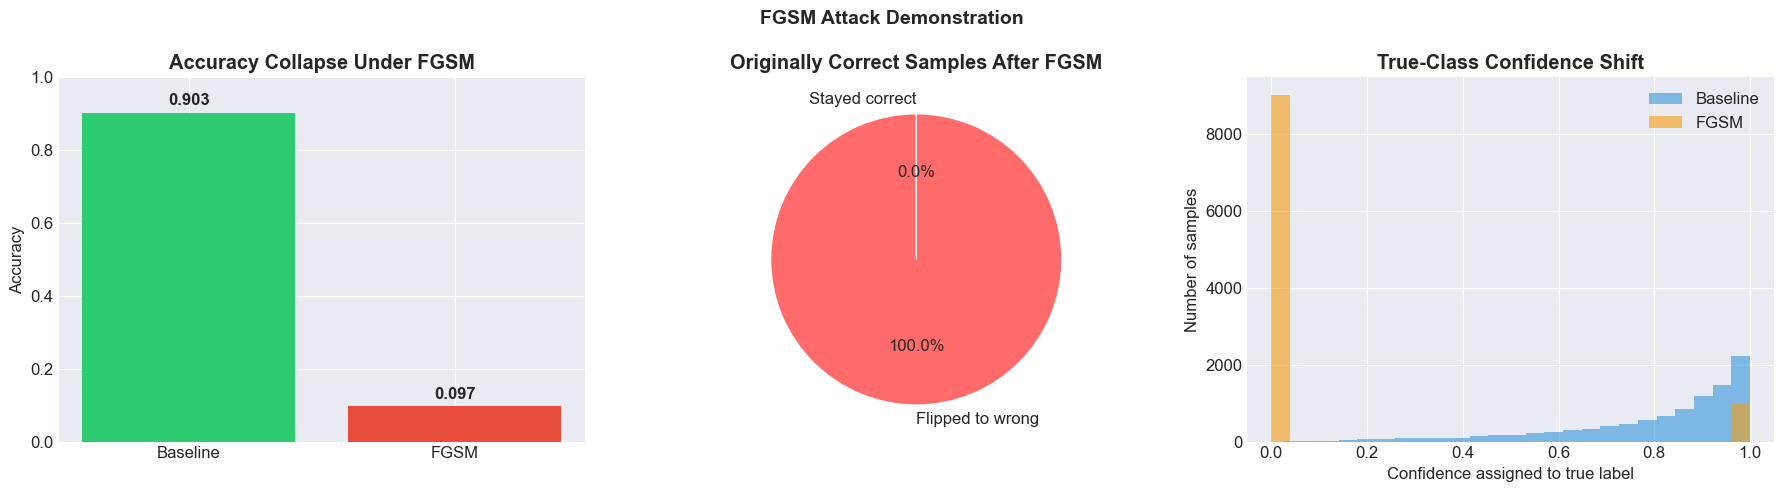

In [49]:
# Visual demonstration of FGSM impact: accuracy drop, flip rate, and confidence shift.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Baseline vs adversarial accuracy.
base_acc = (base_pred == y_test).mean()
axes[0].bar(["Baseline", "FGSM"], [base_acc, fgsm_acc], color=["#2ecc71", "#e74c3c"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Accuracy Collapse Under FGSM", fontweight="bold")
axes[0].set_ylabel("Accuracy")
for i, v in enumerate([base_acc, fgsm_acc]):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

# 2) What happened to originally correct predictions.
flip_count = becomes_wrong.sum()
still_correct = ((fgsm_pred == y_test) & orig_correct).sum()
axes[1].pie(
    [flip_count, still_correct],
    labels=["Flipped to wrong", "Stayed correct"],
    colors=["#ff6b6b", "#4ecdc4"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)
axes[1].set_title("Originally Correct Samples After FGSM", fontweight="bold")

# 3) Confidence on the true class before vs after attack.
base_true_conf = np.where(y_test == 1, base_proba[:, 1], base_proba[:, 0])
fgsm_true_conf = np.where(y_test == 1, fgsm_proba[:, 1], fgsm_proba[:, 0])
axes[2].hist(base_true_conf, bins=25, alpha=0.6, label="Baseline", color="#3498db")
axes[2].hist(fgsm_true_conf, bins=25, alpha=0.6, label="FGSM", color="#f39c12")
axes[2].set_title("True-Class Confidence Shift", fontweight="bold")
axes[2].set_xlabel("Confidence assigned to true label")
axes[2].set_ylabel("Number of samples")
axes[2].legend()

plt.suptitle("FGSM Attack Demonstration", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()